# Random Forest Model
**Michael Maldonado**

### Importing Libraries

In [336]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, plot_roc_curve
from sklearn.preprocessing import StandardScaler
import talib as ta

# If talib is not installed, uncomment and run
# !pip install talib-binary

### Loading data into dataframe

In [353]:
data = pd.read_csv("Data/ETFs/qqq.us.txt", delimiter = ",")
data = data.drop(columns = ["OpenInt"])
data["Date"] = pd.to_datetime(data["Date"])
data = data.set_index("Date")

data.head(5)

,Open,High,Low,Close,Volume
Date,,,,,
1999-03-10,45.722,45.750,44.967,45.665,11700414
1999-03-11,45.994,46.260,44.988,45.880,21670048
1999-03-12,45.721,45.749,44.406,44.770,19553768
1999-03-15,45.101,46.103,44.625,46.052,14245348
1999-03-16,46.253,46.643,45.749,46.447,10971066


Text(0.5, 1.0, 'NASDAQ: QQQ')

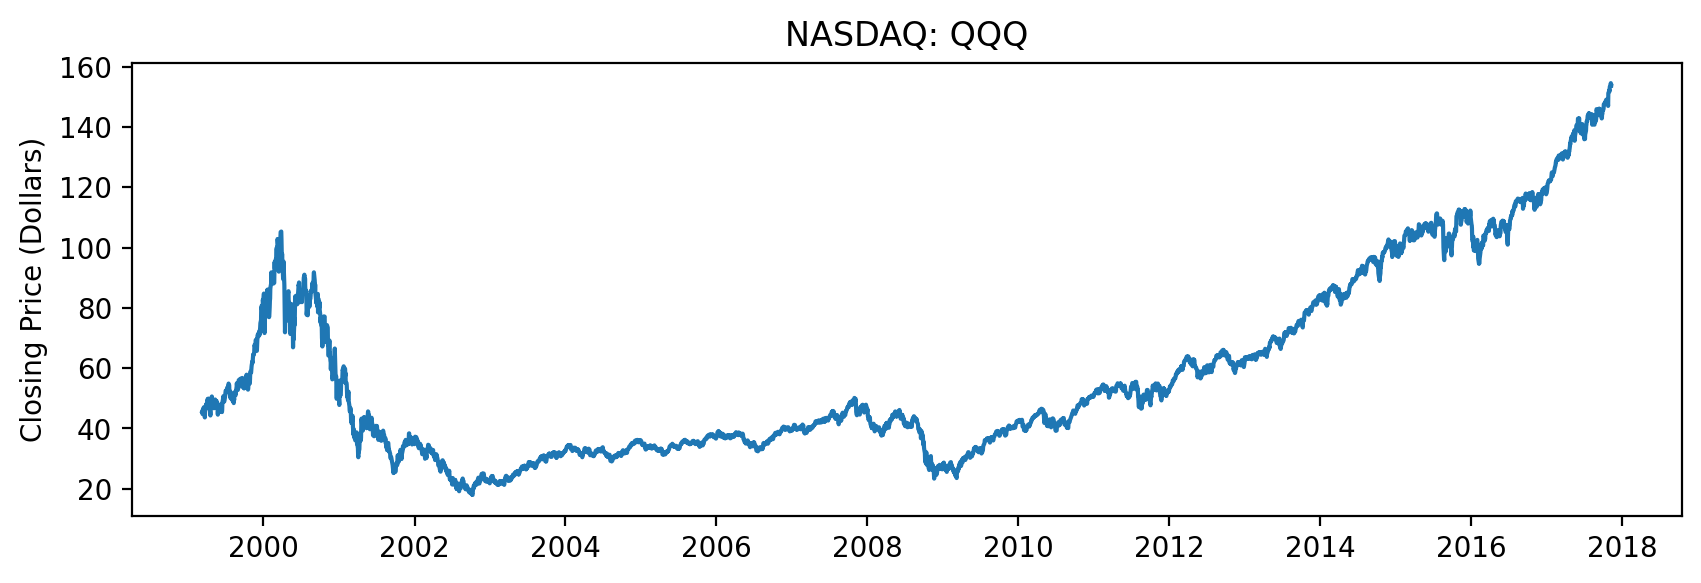

In [354]:
fig = plt.figure(dpi = 200, figsize= (10, 3))
ax = fig.add_subplot(1, 1, 1)
ax.plot(data["Close"])
ax.set_ylabel("Closing Price (Dollars)")
ax.set_title("NASDAQ: QQQ")

### Adding indicators to dataset

In [355]:
# RSI
data["RSI"] = ta.RSI(data["Close"].to_numpy())

# Stochastic Oscillator Slow
data["STOCH"] = ta.STOCH(data["High"].to_numpy(), 
                          data["Low"].to_numpy(), 
                          data["Close"].to_numpy())[0]

# Williams Percent Range
data["WILLR"] = ta.WILLR(data["High"].to_numpy(), 
                          data["Low"].to_numpy(), 
                          data["Close"].to_numpy())

# Moving Average Convergence/Divergence
data["MACD"] = ta.MACD(data["Close"].to_numpy())[0]

# Price Rate of Change
data["PROC"] = data['Close'].transform(lambda x: x.pct_change(periods = 9))

# On Balance Volume
data["OBV"] = ta.OBV(data["Close"].to_numpy(), data["Volume"].to_numpy(np.double))

# Average Directional Movement Index
data["ADX"] = ta.ADX(data["High"].to_numpy(), 
                     data["Low"].to_numpy(), 
                     data["Close"].to_numpy())

# Aroon Oscillator
data["AROON"] = ta.AROONOSC(data["High"].to_numpy(), data["Low"].to_numpy())

# Money Flow Index
data["MFI"] = ta.MFI(data["High"].to_numpy(), 
                     data["Low"].to_numpy(), 
                     data["Close"].to_numpy(), 
                     data["Volume"].to_numpy(np.double))

# Commodity Channel Index
data["CCI"] = ta.CCI(data["High"].to_numpy(), 
                     data["Low"].to_numpy(), 
                     data["Close"].to_numpy())

data.head(5)

,Open,High,Low,Close,Volume,RSI,STOCH,WILLR,MACD,PROC,OBV,ADX,AROON,MFI,CCI
Date,,,,,,,,,,,,,,,
1999-03-10,45.722,45.750,44.967,45.665,11700414,NaN,NaN,NaN,NaN,NaN,11700414.0,NaN,NaN,NaN,NaN
1999-03-11,45.994,46.260,44.988,45.880,21670048,NaN,NaN,NaN,NaN,NaN,33370462.0,NaN,NaN,NaN,NaN
1999-03-12,45.721,45.749,44.406,44.770,19553768,NaN,NaN,NaN,NaN,NaN,13816694.0,NaN,NaN,NaN,NaN
1999-03-15,45.101,46.103,44.625,46.052,14245348,NaN,NaN,NaN,NaN,NaN,28062042.0,NaN,NaN,NaN,NaN
1999-03-16,46.253,46.643,45.749,46.447,10971066,NaN,NaN,NaN,NaN,NaN,39033108.0,NaN,NaN,NaN,NaN


### Cleaning dataset

In [340]:
# Creating column for prediction
data["Prediction"] = data["Close"].transform(lambda x: (x.shift(1) < x) * 1)

# Dropping NaN values
print(f"Before NaN Drop: ROW:{data.shape[0]}, COL:{data.shape[1]}")
data = data.dropna()
print(f"After NaN Drop: ROW:{data.shape[0]}, COL:{data.shape[1]}")

data.head(5)

Before NaN Drop: ROW:7983, COL:16
After NaN Drop: ROW:7950, COL:16


,Open,High,Low,Close,Volume,RSI,STOCH,WILLR,MACD,PROC,OBV,ADX,AROON,MFI,CCI,Prediction
Date,,,,,,,,,,,,,,,,
1986-04-30,0.08389,0.08389,0.08389,0.08389,41071780,58.169668,6.712058e+01,-49.319124,0.003624,0.113633,1.483369e+09,39.219266,21.428571,70.910993,63.584260,0
1986-05-01,0.08389,0.08389,0.08389,0.08389,72229681,58.169668,3.378725e+01,-49.319124,0.003530,0.113633,1.483369e+09,40.443533,21.428571,70.910993,53.714538,0
1986-05-02,0.08389,0.08389,0.08389,0.08389,26909095,58.169668,1.689363e+01,-49.319124,0.003417,0.113633,1.483369e+09,41.580352,21.428571,70.910993,45.938454,0
1986-05-05,0.08389,0.08389,0.08389,0.08389,4325363,58.169668,4.736952e-15,-49.319124,0.003290,0.113633,1.483369e+09,42.635970,21.428571,70.910993,39.451362,0
1986-05-06,0.08389,0.08389,0.08389,0.08389,12937801,58.169668,4.736952e-15,-49.319124,0.003152,0.113633,1.483369e+09,43.616186,21.428571,70.910993,33.054891,0


### Splitting dataset and training model

In [341]:
# Split into training and testing datasets
x_train, x_test, y_train, y_test = train_test_split(data[["RSI", "STOCH", "WILLR", "MACD", "PROC", 
                                                          "OBV", "ADX", "AROON", "MFI", "CCI"]], 
                                                    data["Prediction"], 
                                                    random_state = 0)
# Create a Random Forest Classifier
classifier = RandomForestClassifier(n_estimators = 1000, oob_score = True, criterion = "gini", random_state = 0)

# Fit the data to the model
classifier.fit(x_train, y_train)

# Make predictions
y_pred = classifier.predict(x_test)

# Print the Accuracy of the model
print(f"Classifier Accuracy (%): {accuracy_score(y_test, y_pred, normalize = True) * 100.0}")

Classifier Accuracy (%): 77.41448692152917


In [342]:
# Split into training and testing datasets
x_trainr, x_testr, y_trainr, y_testr = train_test_split(data[["RSI", "STOCH", "WILLR", "MACD", "PROC", 
                                                          "OBV", "ADX", "AROON", "MFI", "CCI"]], 
                                                    data["Close"], 
                                                    random_state = 0)
# Create a Random Forest Classifier
regressor = RandomForestRegressor(n_estimators = 1000, random_state = 0)

# Fit the data to the model
regressor.fit(x_trainr, y_trainr)

# Make predictions
y_predr = regressor.predict(x_testr)

# Print the Accuracy of the model
print(f"Regressor Accuracy (%): {regressor.score(x_testr, y_testr) * 100}")

Regressor Accuracy (%): 90.0440030207603


### Plotting regressor predicted prices

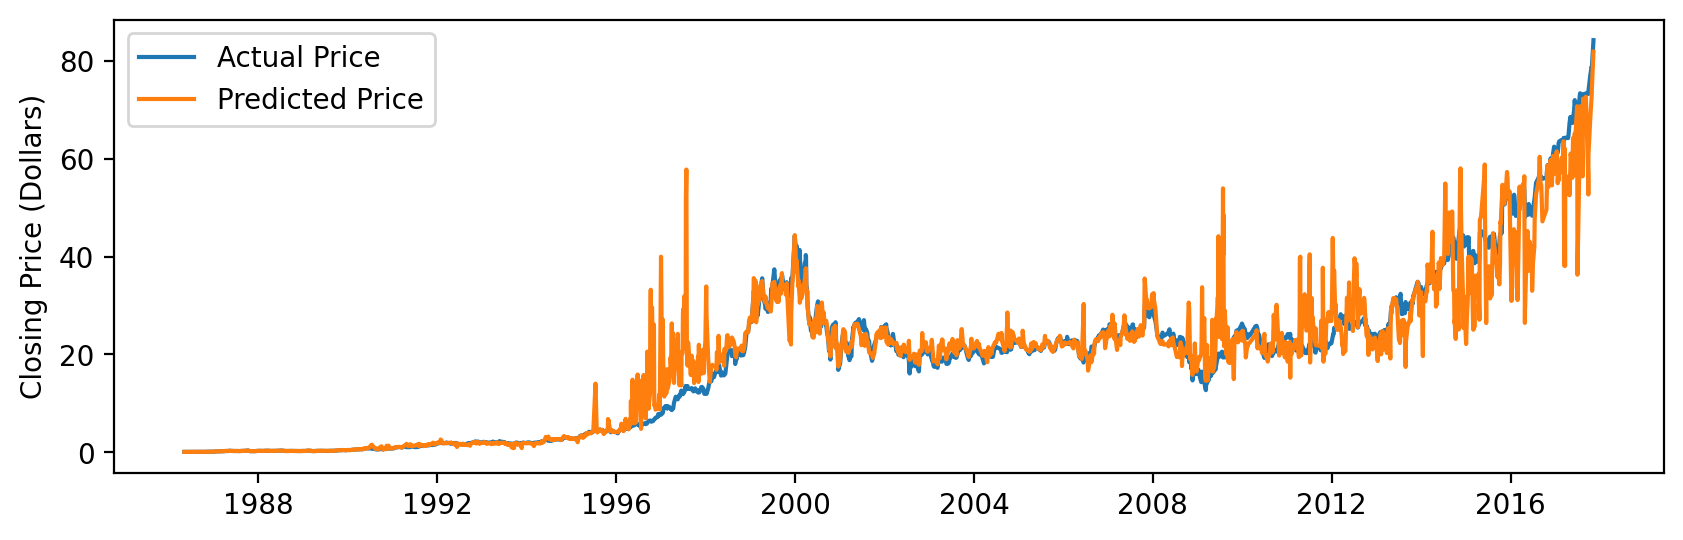

In [350]:
predicted = pd.Series(data = y_predr, index = y_testr.index)
predicted = predicted.sort_index()

actual = y_testr.sort_index()

fig = plt.figure(dpi = 200, figsize= (10, 3))
ax = fig.add_subplot(1, 1, 1)
actual_line = ax.plot(actual, label = "Actual Price")
predicted_line = ax.plot(predicted, label = "Predicted Price")
ax.set_ylabel("Closing Price (Dollars)")
ax.legend()